# STalign parity: `xenium-starmap-alignment.ipynb`

Executed one-to-one replay of [the pinned upstream notebook](https://github.com/JEFworks-Lab/STalign/blob/b2068edc98974efa54537eca194736e177bbe11d/docs/notebooks/xenium-starmap-alignment.ipynb).

Status: `compared`. 


In [1]:
# per-variable relative L2: upstream STalign vs the squidpy JAX port


{
  "A relative L2": 0.0003004026516444345,
  "df1 relative L2": 0.0,
  "df1[cell_area] median abs delta": 0.0,
  "df1[nucleus_area] median abs delta": 0.0,
  "df1[x_centroid] median abs delta": 0.0,
  "df1[y_centroid] median abs delta": 0.0,
  "df2[Maintype_Symbol] label disagreement": 0.0,
  "df2[Maintype_Symbol] label set jaccard": 1.0,
  "df2[Maintype_Symbol] labels only squidpy": 0.0,
  "df2[Maintype_Symbol] labels only upstream": 0.0,
  "df2[NAME] label disagreement": 0.0,
  "df2[NAME] label set jaccard": 1.0,
  "df2[NAME] labels only squidpy": 0.0,
  "df2[NAME] labels only upstream": 0.0,
  "df2[Subtype_Symbol] label disagreement": 0.0,
  "df2[Subtype_Symbol] label set jaccard": 1.0,
  "df2[Subtype_Symbol] labels only squidpy": 0.0,
  "df2[Subtype_Symbol] labels only upstream": 0.0,
  "df2[Tissue_Symbol] label disagreement": 0.0,
  "df2[Tissue_Symbol] label set jaccard": 1.0,
  "df2[Tissue_Symbol] labels only squidpy": 0.0,
  "df2[Tissue_Symbol] labels only upstream": 0.0,
  "df

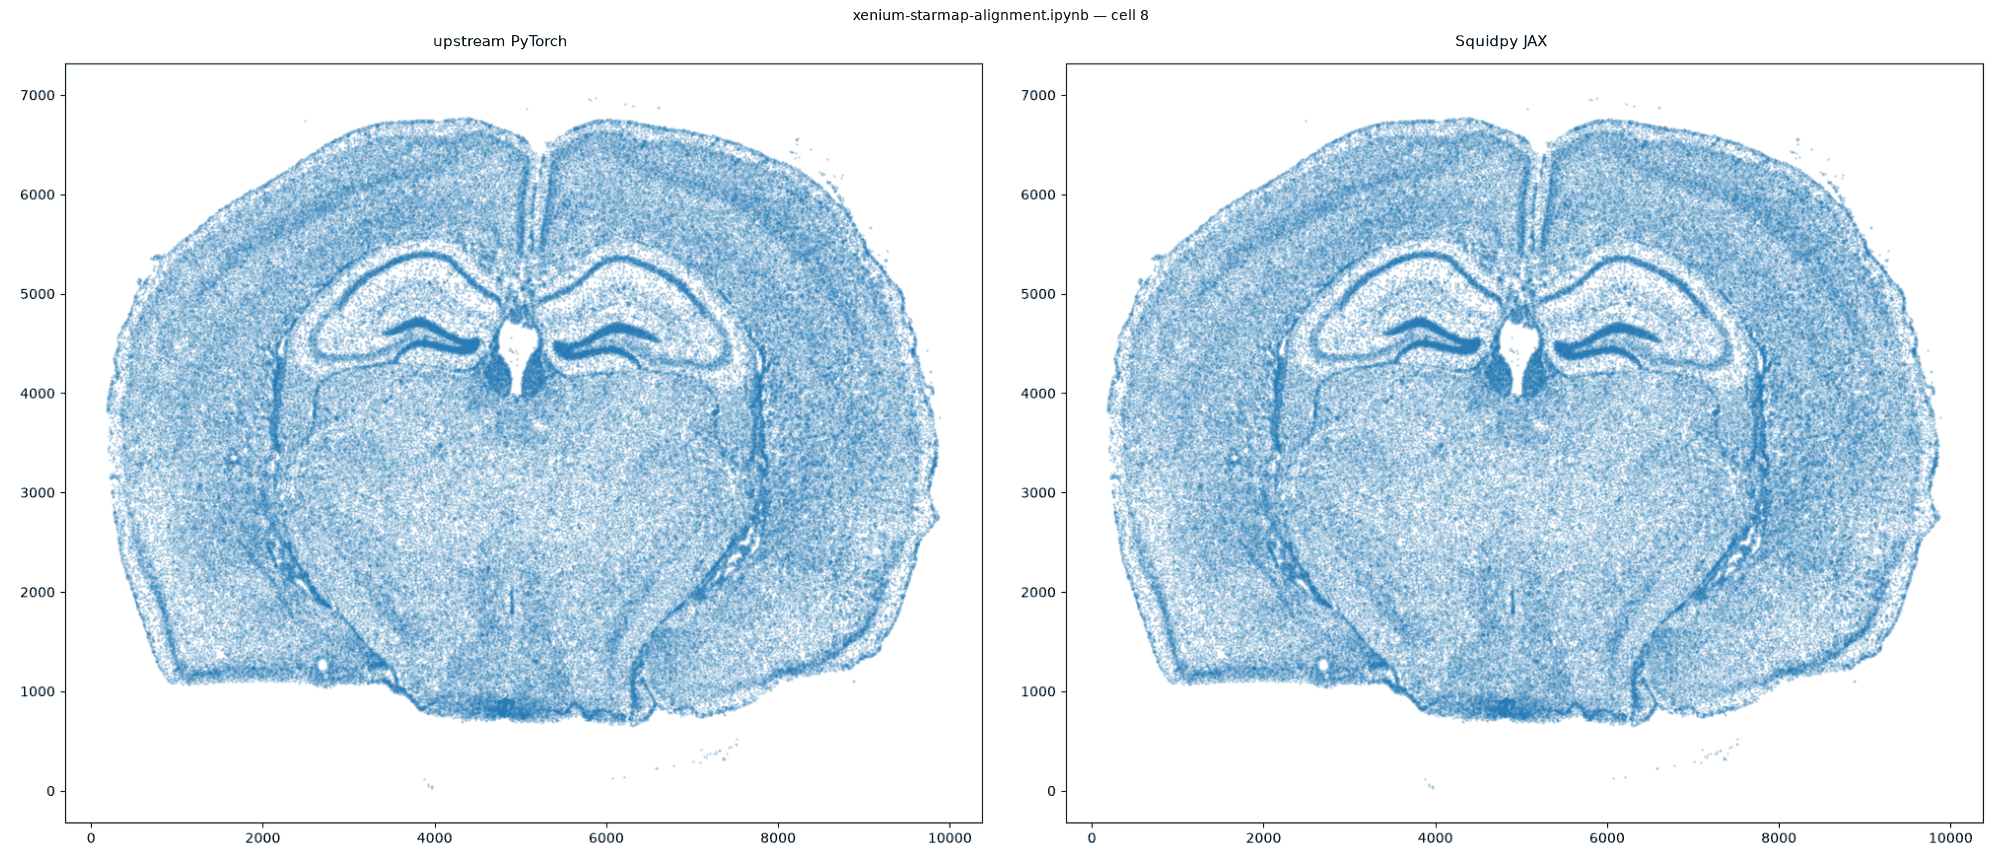

In [2]:
# get cell centroid coordinates
xI = np.array(df1['x_centroid'])
yI = np.array(df1['y_centroid'])

# plot
fig,ax = plt.subplots()
ax.scatter(xI,yI,s=1,alpha=0.2)

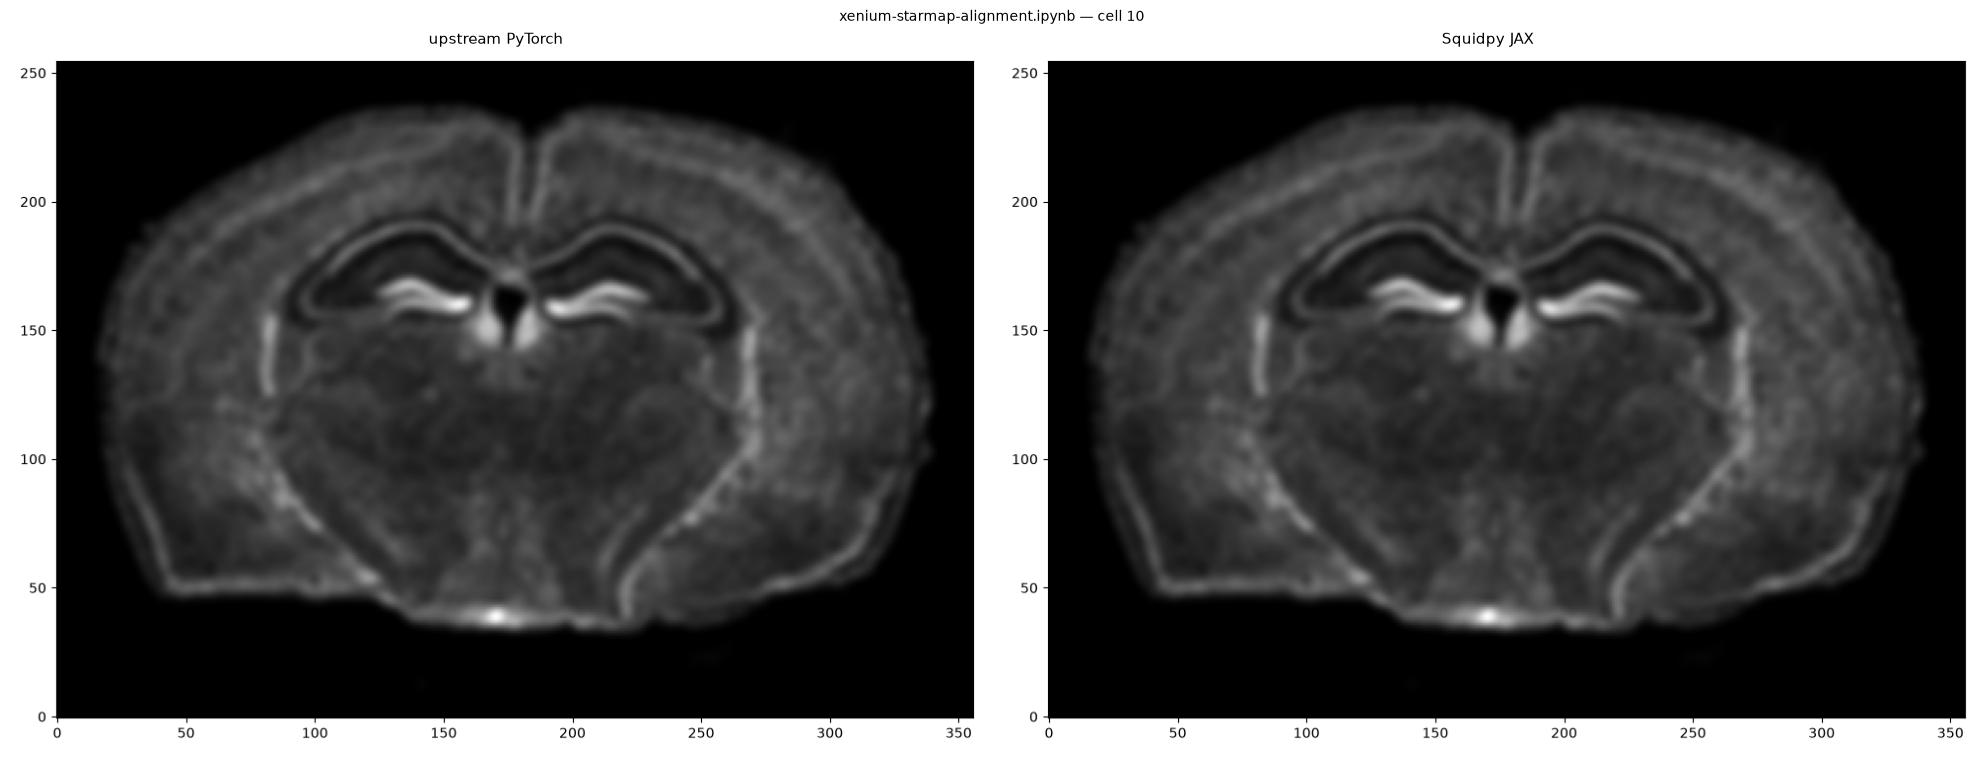

In [3]:
# rasterize at 30um resolution (assuming positions are in um units) and plot
XI,YI,I,fig = STalign.rasterize(xI,yI)

# plot
ax = fig.axes[0]
ax.invert_yaxis()

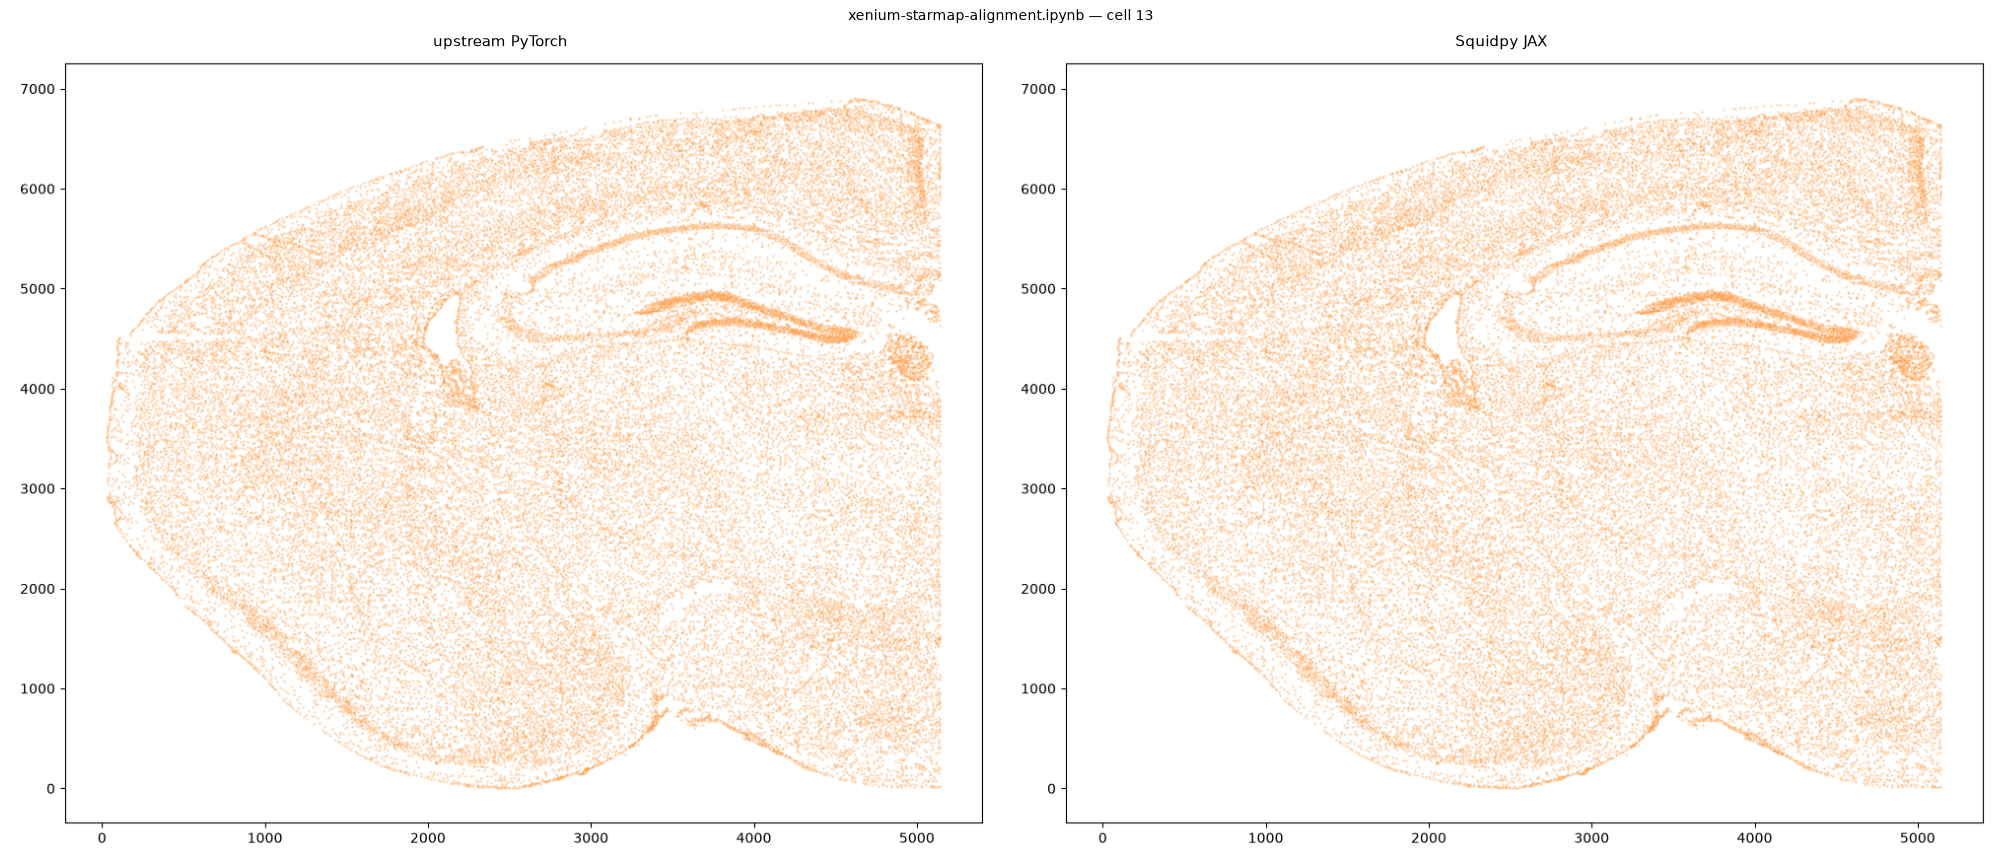

In [4]:
# get cell centroids
xJ = np.array(df2['Y'])/5 # convert to similar scale
yJ = np.array(df2['X'])/5

# flip
yJ = yJ.max() - yJ

# plot
fig,ax = plt.subplots()
ax.scatter(xJ,yJ,s=1,alpha=0.2,c='#ff7f0e')

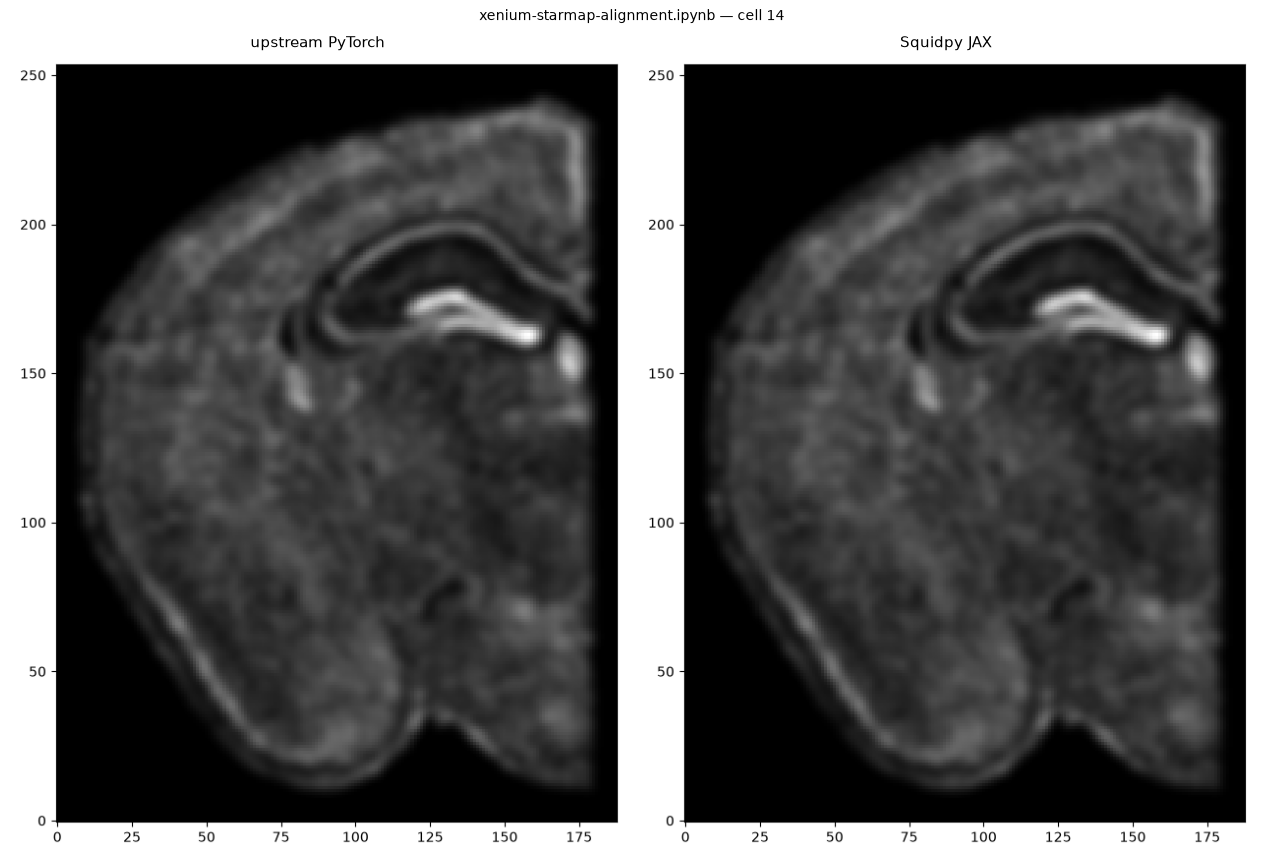

In [5]:
# rasterize and plot
XJ,YJ,J,fig = STalign.rasterize(xJ,yJ)
ax = fig.axes[0]
ax.invert_yaxis()

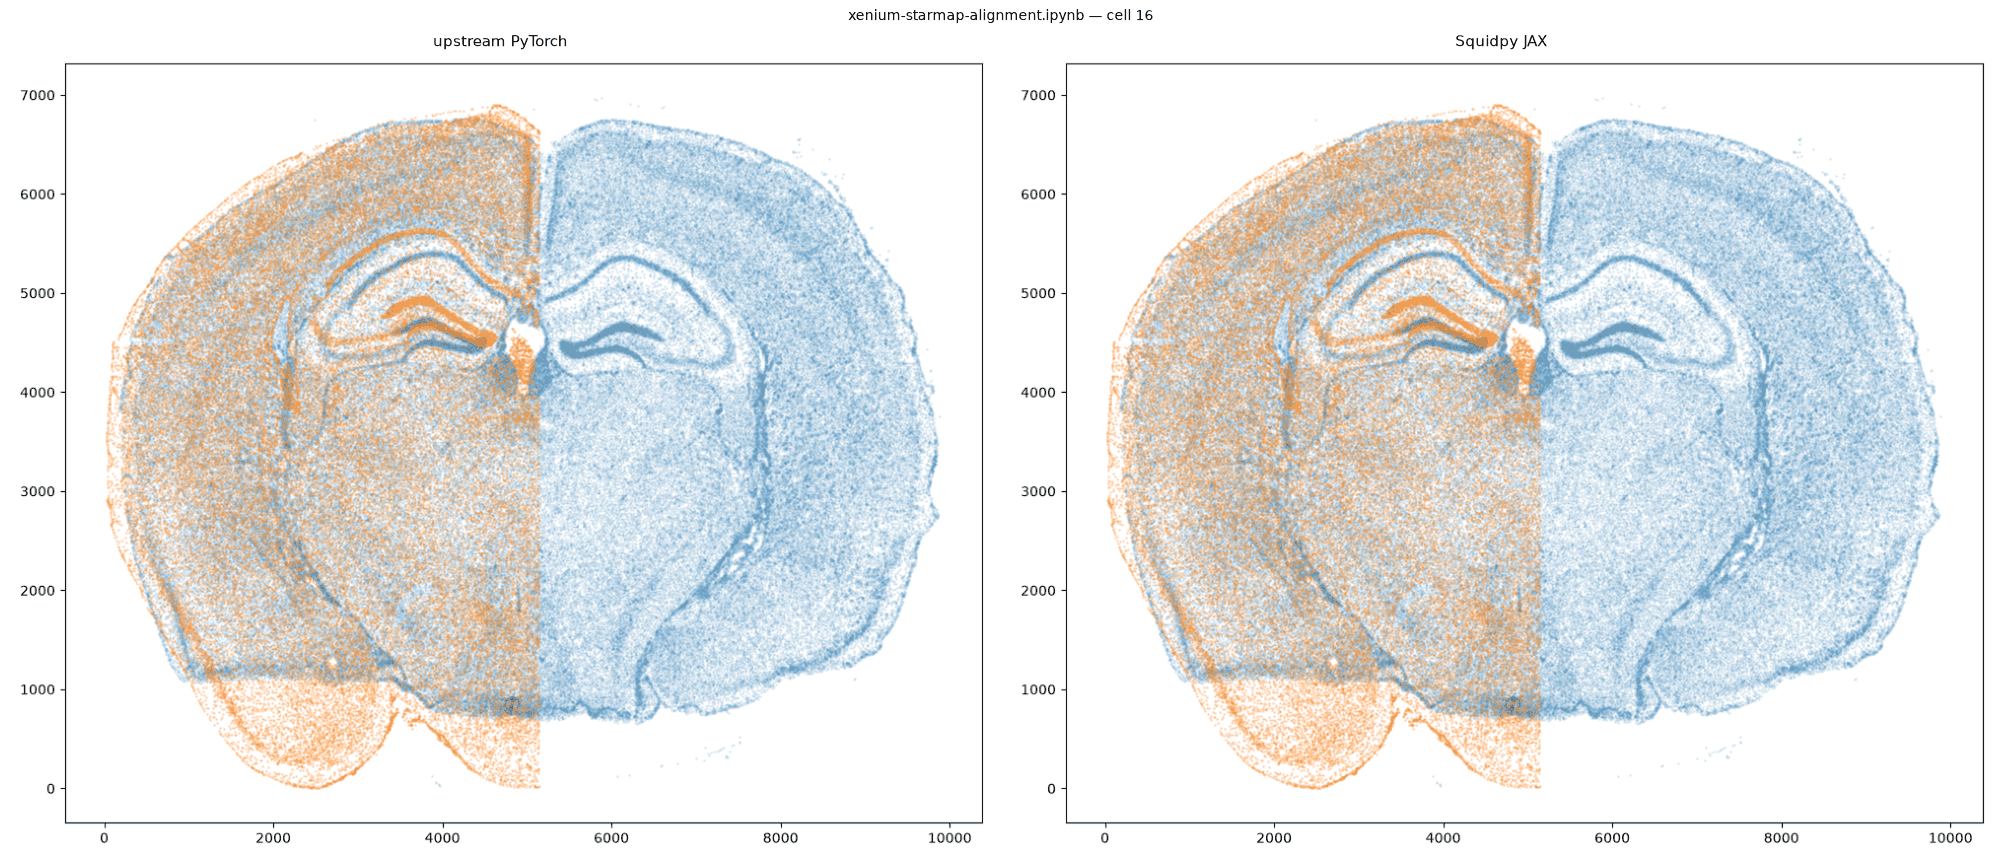

In [6]:
# plot
fig,ax = plt.subplots()
ax.scatter(xI,yI,s=1,alpha=0.1)
ax.scatter(xJ,yJ,s=1,alpha=0.2)

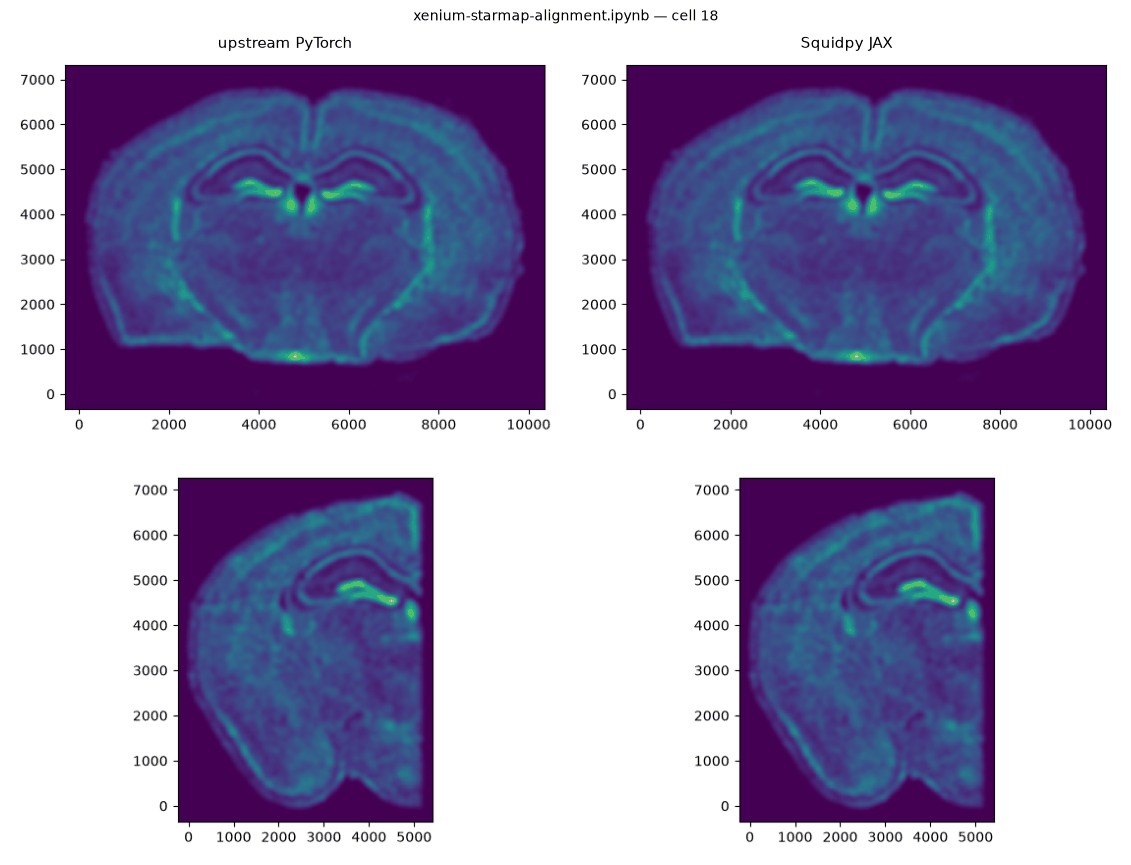

In [7]:
# get extent of images
extentI = STalign.extent_from_x((YI,XI))
extentJ = STalign.extent_from_x((YJ,XJ))

# plot rasterized images
fig,ax = plt.subplots(2,1)
ax[0].imshow((I.transpose(1,2,0).squeeze()), extent=extentI) 
ax[1].imshow((J.transpose(1,2,0).squeeze()), extent=extentJ) 
ax[0].invert_yaxis()
ax[1].invert_yaxis()

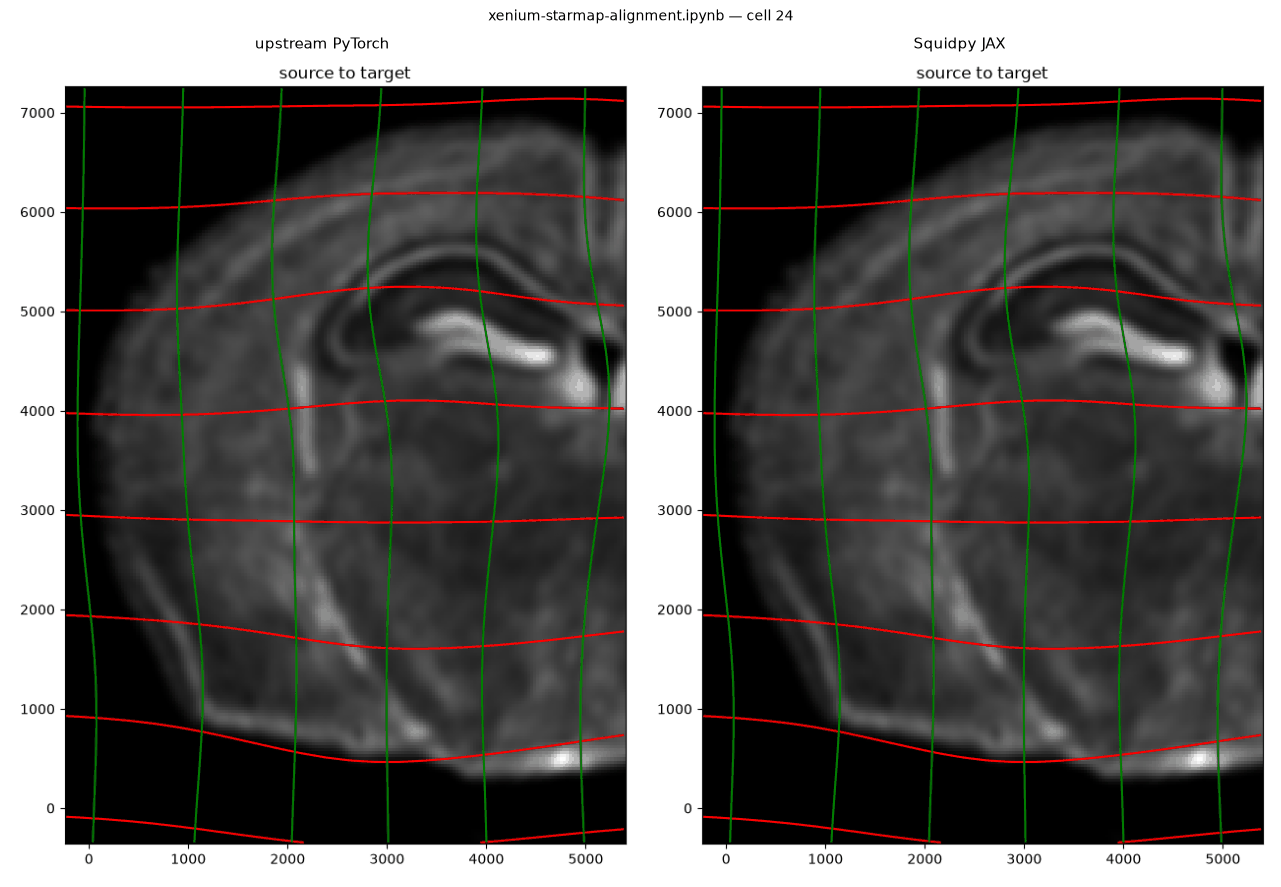

In [8]:
# apply transform
phii = STalign.build_transform(xv,v,A,XJ=[YJ,XJ],direction='b')
phiI = STalign.transform_image_source_to_target(xv,v,A,[YI,XI],Ifoo,[YJ,XJ])

#switch tensor from cuda to cpu for plotting with numpy
if phii.is_cuda:
    phii = phii.cpu()
if phiI.is_cuda:
    phiI = phiI.cpu()

# plot with grids
fig,ax = plt.subplots()
levels = np.arange(-100000,100000,1000)
ax.contour(XJ,YJ,phii[...,0],colors='r',linestyles='-',levels=levels)
ax.contour(XJ,YJ,phii[...,1],colors='g',linestyles='-',levels=levels)
ax.set_aspect('equal')
ax.set_title('source to target')
ax.imshow(phiI.permute(1,2,0)/torch.max(phiI),extent=extentJ)
ax.invert_yaxis()

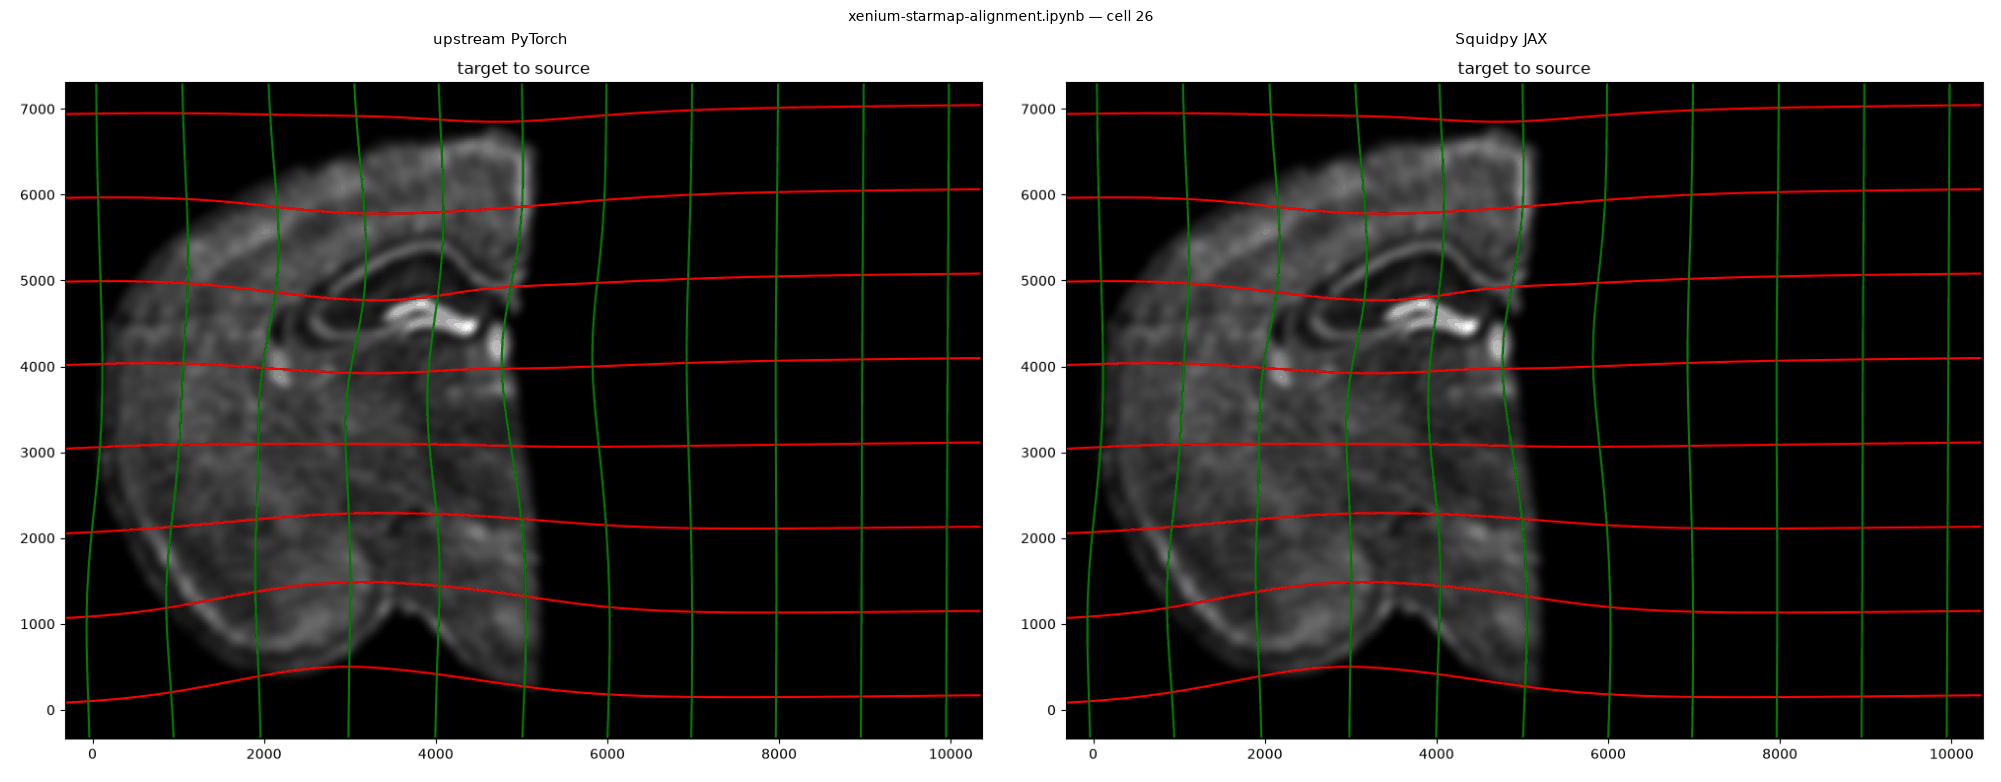

In [9]:
# transform is invertible
phi = STalign.build_transform(xv,v,A,XJ=[YI,XI],direction='f')
phiiJ = STalign.transform_image_target_to_source(xv,v,A,[YJ,XJ],Jfoo,[YI,XI])

#switch tensor from cuda to cpu for plotting with numpy
if phi.is_cuda:
    phi = phi.cpu()
if phiiJ.is_cuda:
    phiiJ = phiiJ.cpu()

# plot with grids
fig,ax = plt.subplots()
levels = np.arange(-100000,100000,1000)
ax.contour(XI,YI,phi[...,0],colors='r',linestyles='-',levels=levels)
ax.contour(XI,YI,phi[...,1],colors='g',linestyles='-',levels=levels)
ax.set_aspect('equal')
ax.set_title('target to source')
ax.imshow(phiiJ.permute(1,2,0)/torch.max(phiiJ),extent=extentI)
ax.invert_yaxis()

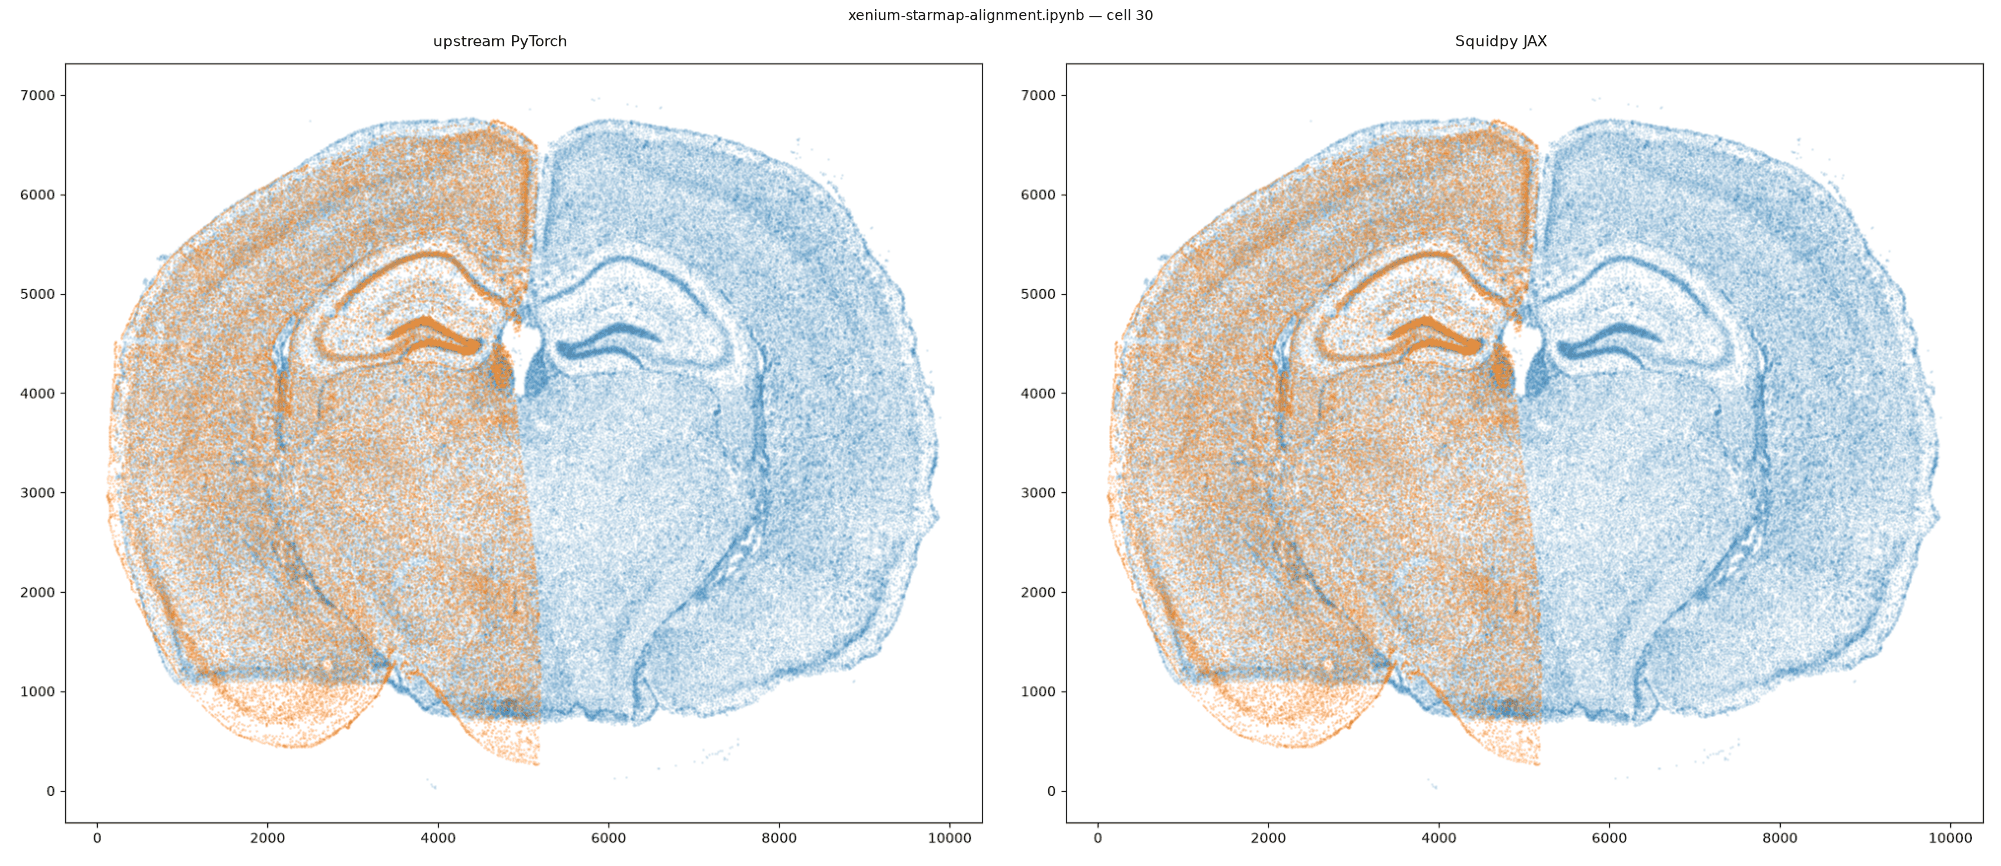

In [10]:
# plot results
fig,ax = plt.subplots()
ax.scatter(tpointsI[0,:],tpointsI[1,:],s=1,alpha=0.1) 
ax.scatter(tpointsJ[:,1],tpointsJ[:,0],s=1,alpha=0.2) # also needs to plot as y,x not x,y

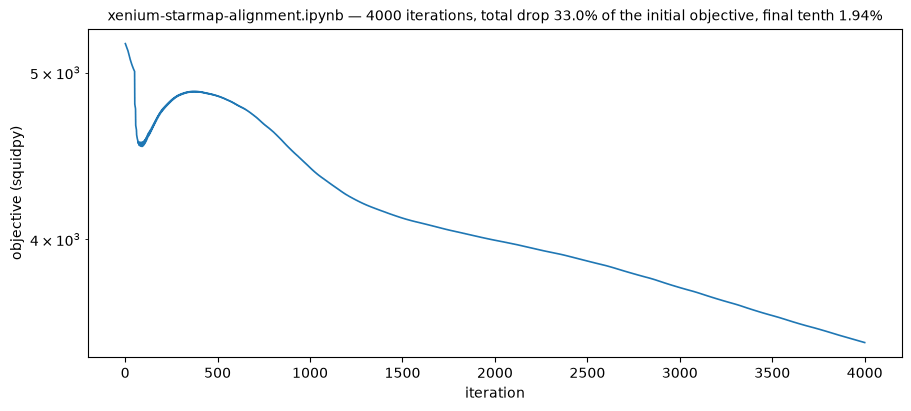

In [11]:
# upstream vs squidpy — figure 10
